In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('46400_AS05_Loads_stats_Spring2026.csv', sep=';', skiprows=[1],
                  parse_dates=['rname'], date_parser=lambda x: pd.to_datetime(x, format='%Y%m%d%H%M', errors='coerce'))
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_20640\2035159915.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv('46400_AS05_Loads_stats_Spring2026.csv', sep=';', skiprows=[1],


,rname,Wsp_44m,Wsp_44m_stdev,Wdir_41m,ROT,yaw,pa,po,wsn,MyTB_mean,...,MyA1_DEL9,MyA1_DEL12,MxA1_mean,MxA1_stdev,MxA1_min,MxA1_max,MxA1_DEL3,MxA1_DEL6,MxA1_DEL9,MxA1_DEL12
0,2017-01-01 20:40:00,6.36,0.66,282.66,20.55,278.61,-1.77,175.50,6.81,-887.597,...,269.619,276.271,-211.509,47.3831,-360.007,37.0285,74.6592,142.7520,195.733,231.585
1,2017-01-01 20:50:00,6.68,0.47,283.25,20.30,278.61,-1.79,169.60,6.71,-855.687,...,266.767,272.674,-205.411,32.0547,-331.265,-118.0460,53.1841,86.3817,111.966,129.650
2,2017-01-01 21:00:00,6.24,0.46,278.10,18.60,278.61,-1.67,133.07,6.11,-690.603,...,266.548,273.040,-165.332,30.6360,-274.459,-79.2139,49.5711,80.4282,103.191,118.637
3,2017-01-01 21:20:00,6.07,0.50,280.70,18.88,278.61,-1.73,133.55,6.22,-708.469,...,267.087,273.637,-169.816,38.8028,-303.106,-82.3943,49.3179,84.2135,112.190,130.894
4,2017-01-01 21:30:00,5.90,0.47,283.28,19.25,278.61,-1.74,121.60,6.41,-684.019,...,266.315,272.631,-167.399,30.2279,-295.519,-84.0601,50.8816,84.6000,110.266,127.860


Plotting to check unusual data points

In [18]:
def plot_wsp_with_stdev(df):
    plt.figure(figsize=(12, 4))
    
    plt.plot(df['rname'], df["Wsp_44m"], label="Wsp_44m (mean)")
    plt.plot(df['rname'], df["Wsp_44m_stdev"], label="Wsp_44m_stdev")
    
    plt.title("Wind Speed at 44m (Mean & Std Dev)")
    plt.xlabel("Time")
    plt.ylabel("Wind Speed (m/s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

From a first visualization, it is easy to spot some flawed values (Wsp ~ 1e7) so a filter for a maximum velocity of 30 m/s is applied.

Removed 46 rows where Wsp_44m >= 30 m/s


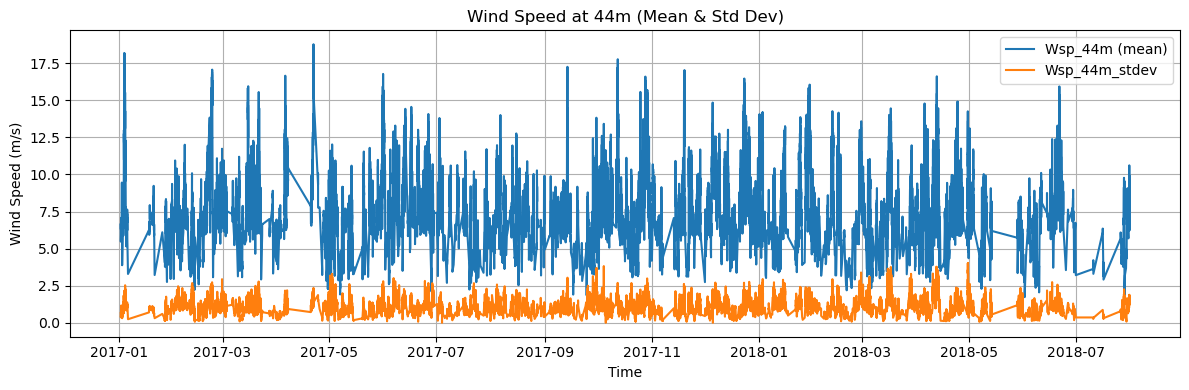

In [32]:
df_wsp_filter = df[df['Wsp_44m'] < 30]
removed = len(df) - len(df_wsp_filter)
print(f"Removed {removed} rows where Wsp_44m >= 30 m/s")
plot_wsp_with_stdev(df_wsp_filter)

In [24]:
meteo_cols = ["Wdir_41m"]  # wind direction

operational_cols = [
    "ROT",   # rotor velocity
    "yaw",
    "pa",    # pitch angle
    "po",    # active power
    "wsn"
]

def plot_columns(df, columns, title_prefix):
    for col in columns:
        if col not in df.columns:
            print(f"Skipping {col} (not found)")
            continue
        
        plt.figure(figsize=(12, 4))
        plt.plot(df['rname'], df[col])
        plt.title(f"{title_prefix}: {col}")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

Meteorological and operational parameters plots.

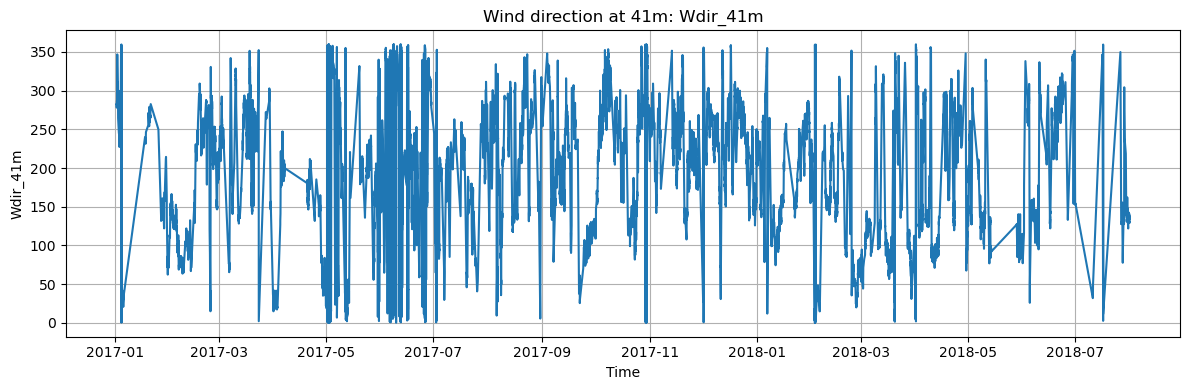

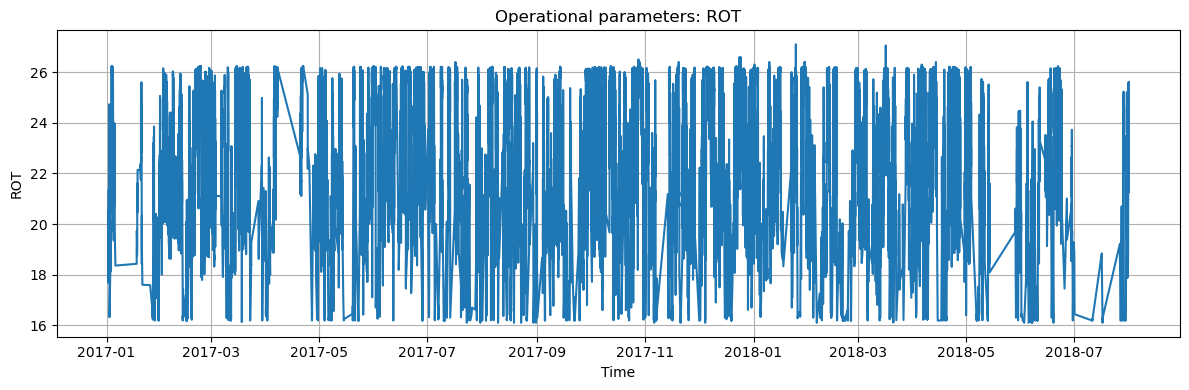

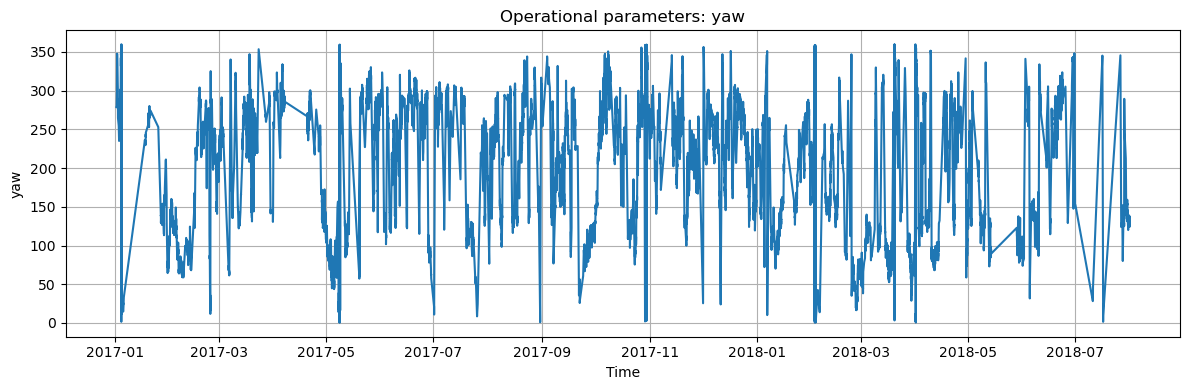

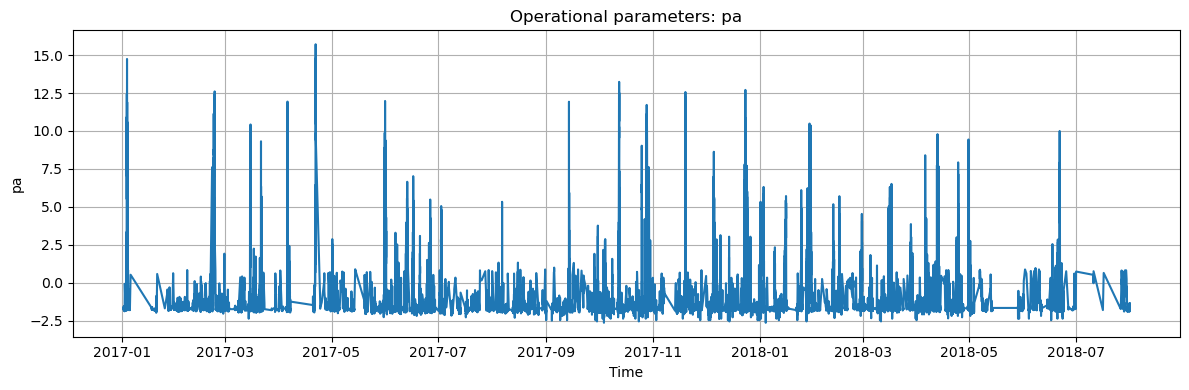

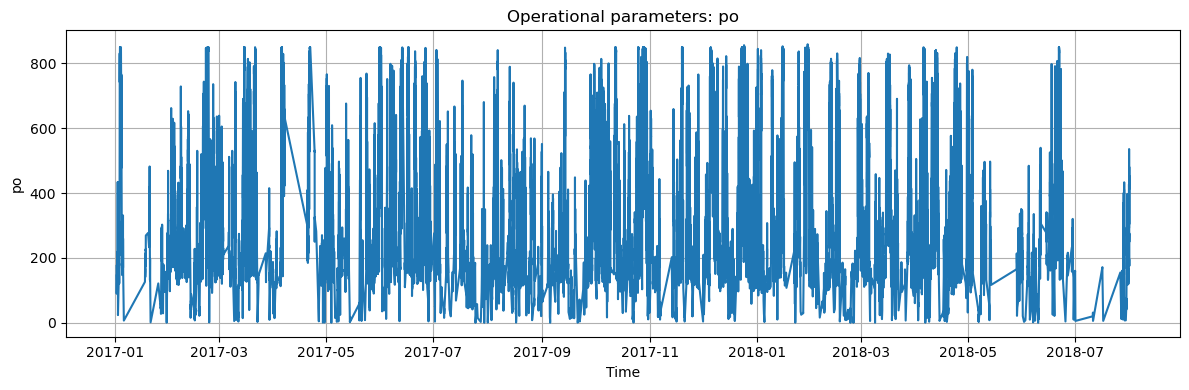

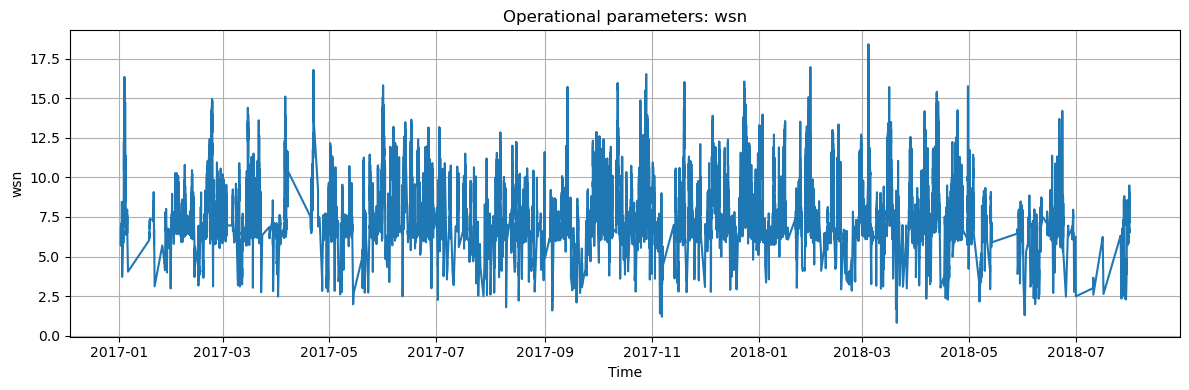

In [25]:
plot_columns(df, meteo_cols, "Wind direction at 41m")

plot_columns(df, operational_cols, "Operational parameters")

Ensuring rotor speed limits are respected.

In [ ]:
rotor_limits = ((df['ROT'] > 16) & (df['ROT'] < 26.5))
filtered_df = df[rotor_limits]
print(f"Removed {len(df) - len(filtered_df)} rows based on ROT limits")

TypeError: Cannot perform 'rand_' with a dtyped [float64] array and scalar of type [bool]